1. Data loaded
2. CNT cohort + all inputs
3. Neural Network , RF, SVM
4. Average balanced accuracy of model
5. Test case accuracy

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#!/usr/bin/env python
# coding: utf-8
from tabulate import tabulate
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
#import torch.nn.functional as F
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
#pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from sklearn.metrics import balanced_accuracy_score
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from sklearn.metrics import balanced_accuracy_score

Collating all data of boolean, erk-akt, pten,egf for each cohort

In [ ]:
#FIRST INPUT CSV -> boolean + ncg data
df_boolean_and_ncg_ip = pd.read_csv('/Shapley_PCa/boolean_input_output_default_run_Testo0.csv')
df_boolean_and_ncg_ip.head() #this csv has time series data for boolean+ncg value at all iterations
result_df = df_boolean_and_ncg_ip[df_boolean_and_ncg_ip['step'] == 'SS'].reset_index(drop=True)
#result_df is a df size 1920 x 26 -> after exractting SS rows for each iteration
#print(result_df.head())
value_counts=result_df['cohort'].value_counts()
# Convert the result to a DataFrame for better presentation
count_df = pd.DataFrame({'Cohort': value_counts.index, 'Count': value_counts.values})
#count_df - we have 640 data points for each of the three cohorts - CNT, BR, TF
#print(count_df)

#we now extract 640 points in each cohort to a separate df
df_boolean_and_ncg_CNT= result_df[result_df['cohort']=='CNT'].reset_index(drop=True)
df_boolean_and_ncg_BR= result_df[result_df['cohort']=='BR'].reset_index(drop=True)
df_boolean_and_ncg_TF= result_df[result_df['cohort']=='TF'].reset_index(drop=True)
df_boolean_and_ncg_TF.head()


In [ ]:
#SECOND INPUT CSV -> PTEN, EGF analog data
df_pten_egf_ip=pd.read_csv('/Shapley_PCa/bool_input_threshold_case_spec_modified.csv')
#df_pten_egf_ip.head()

##we now extract 640 points in each cohort to a separate df
df_pten_egf_CNT= df_pten_egf_ip[df_pten_egf_ip['cohort']=='CNT'].reset_index(drop=True)
df_pten_egf_BR= df_pten_egf_ip[df_pten_egf_ip['cohort']=='BR'].reset_index(drop=True)
df_pten_egf_TF= df_pten_egf_ip[df_pten_egf_ip['cohort']=='TF'].reset_index(drop=True)
df_pten_egf_TF.head()


In [ ]:
#THIRD INPUT CSV
df_erkakt_ip= pd.read_csv('/Shapley_PCa/pp_SS_boolean_input_threshold_0.05_validation_v1.csv')
df_erkakt_ip.head()

#we now extract 640 points in each cohort to a separate df
df_erkakt_CNT= df_erkakt_ip[df_erkakt_ip['cohort']=='CNT'].reset_index(drop=True)
df_erkakt_BR= df_erkakt_ip[df_erkakt_ip['cohort']=='BR'].reset_index(drop=True)
df_erkakt_TF= df_erkakt_ip[df_erkakt_ip['cohort']=='TF'].reset_index(drop=True)
df_erkakt_BR.head()

In [ ]:
#now combine entries for all inputs in a single df (one for each cohort)
df_CNT = pd.concat([df_boolean_and_ncg_CNT,df_erkakt_CNT[['ERK_PP_CONC','AKT_PP_CONC']],df_pten_egf_CNT[['PTEN','EGF_nM']] ], axis=1)
df_BR = pd.concat([df_boolean_and_ncg_BR,df_erkakt_BR[['ERK_PP_CONC','AKT_PP_CONC']],df_pten_egf_BR[['PTEN','EGF_nM']] ], axis=1)
df_TF = pd.concat([df_boolean_and_ncg_TF,df_erkakt_TF[['ERK_PP_CONC','AKT_PP_CONC']],df_pten_egf_TF[['PTEN','EGF_nM']] ], axis=1)
print(df_TF)

    step    iter  AKT_PP  TP53  ERK_PP  E2F1  PTEN  WIP1  CDKN1A  ATM  ...  \
0     SS  iter 1       1     0       0     1     1     1       1    0  ...   
1     SS  iter 2       0     0       0     0     1     1       0    0  ...   
2     SS  iter 3       1     1       0     0     1     1       1    0  ...   
3     SS  iter 4       1     0       0     1     1     1       0    0  ...   
4     SS  iter 5       0     1       0     0     1     1       0    0  ...   
..   ...     ...     ...   ...     ...   ...   ...   ...     ...  ...  ...   
635   SS  iter 4       0     0       0     1     1     1       0    0  ...   
636   SS  iter 5       0     1       0     0     1     1       0    0  ...   
637   SS  iter 6       0     0       0     1     1     1       0    0  ...   
638   SS  iter 7       0     0       0     1     1     1       0    0  ...   
639   SS  iter 8       1     1       0     0     1     1       1    0  ...   

     CCNG1  BCL2  cohort    case       NCG        ncg_cat  ERK_

Function "evaluate_model" to fit different ML methods to the same data set

In [ ]:
# #Function to define the evaluation logic once and then call it for each method, making the code more concise
# Parameters:
# 1.threshold - ncg threhold used to define the binary class in output
# 2. model - ML method used
# 3,4,5,6. X_train, y_train,X_test,y_test - final input to model after trest train split, scaling and smote
# 7. n_splits - no of splits for kfold cross validation
# 8. random_state

def evaluate_model(threshold,model, X_train, y_train, X_test, y_test, n_splits=5, random_state=42):
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    balanced_accuracies = []

    for train_index, val_index in kf.split(X_train, y_train):
        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

        if model == nn_model :
          model.fit(X_train_fold, y_train_fold, epochs=10)
        else :
          model.fit(X_train_fold, y_train_fold)

        # Predict on validation set
        # Evaluate on the held-out test set

        y_pred = (model.predict(X_val_fold) > 0.5).astype("int64")
        #print(y_val_fold)
        #print(y_pred)
        # Calculate balanced accuracy for this fold
        balanced_accuracy = balanced_accuracy_score(y_val_fold, y_pred)
        balanced_accuracies.append(balanced_accuracy)

    # Calculate average and standard deviation of balanced accuracies
    avg_balanced_accuracy = np.mean(balanced_accuracies)
    std_balanced_accuracy = np.std(balanced_accuracies)

    # Evaluate on the held-out test set
    test_pred = (model.predict(X_test) > 0.5).astype("int64")
    #print(test_pred)
    #print(y_test)
    test_accuracy = balanced_accuracy_score(y_test, test_pred)

    return model, threshold, avg_balanced_accuracy, std_balanced_accuracy, test_accuracy




In [ ]:
thresholds = np.arange(-0.2, 0.5, 0.05).tolist() #list of ncg threholds to check for binary classification based ML fits
no_of_thresholds=len(thresholds)
print(no_of_thresholds)

14


ANALYSIS USING ALL COHORTS AS INPUT

In [ ]:
# Concatenate row-wise
df_total = pd.concat([df_CNT, df_BR, df_TF], axis=0)

# Reset index
df_total.reset_index(drop=True, inplace=True)
print(df_total)

     step    iter  AKT_PP  TP53  ERK_PP  E2F1  PTEN  WIP1  CDKN1A  ATM  ...  \
0      SS  iter 1       0     0       0     1     1     1       0    0  ...   
1      SS  iter 2       1     0       0     1     1     1       0    0  ...   
2      SS  iter 3       0     0       0     0     1     1       0    0  ...   
3      SS  iter 4       1     1       0     0     1     1       1    0  ...   
4      SS  iter 5       1     0       0     1     1     1       0    0  ...   
...   ...     ...     ...   ...     ...   ...   ...   ...     ...  ...  ...   
1915   SS  iter 4       0     0       0     1     1     1       0    0  ...   
1916   SS  iter 5       0     1       0     0     1     1       0    0  ...   
1917   SS  iter 6       0     0       0     1     1     1       0    0  ...   
1918   SS  iter 7       0     0       0     1     1     1       0    0  ...   
1919   SS  iter 8       1     1       0     0     1     1       1    0  ...   

      CCNG1  BCL2  cohort    case       NCG        

In [ ]:

from tabulate import tabulate
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
#We now base binary classification of outputs on different ncg thresholds
# Iterate over thresholds and fit models
#final results are stored in a dataframe combined_df
# Define headers
headers = ["Method","NCG Threshold", "Average Balanced Accuracy", "Std Dev of Balanced Accuracy", "Test Balanced Accuracy"]
combined_df_total = pd.DataFrame(columns=headers)

for threshold in thresholds: #looping the evaluate model function over different thresholds

    # defining inputs as X
    X = df_total[["AKT_PP","TP53","ERK_PP","E2F1","PTEN","WIP1","CDKN1A","ATM","BAX","CASP9","MDM4","CDK1","CDK2","AR","RB1","ARF","Raf_P","MDM2","CCNG1","BCL2","ERK_PP_CONC","AKT_PP_CONC"]] #,"PTEN", "EGF_nM"]] #[["ERK_PP_CONC", "AKT_PP_CONC"]] #,"PTEN_analog", "EGF"
    # Add an output column to binary based on the ncg threshold
    df_total['binary_class'] = (df_total['NCG'] > threshold).astype(int)
    y = df_total['binary_class']

    # Check if there are at least two unique classes in the binary output
    unique_classes = df_total['binary_class'].unique()
    if len(unique_classes) < 2:
        print(f"Skipping threshold {threshold} as it results in only one class in the binary output.")
        continue
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Apply SMOTE to the training set only
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

    # print("Neural Network")
    nn_model = Sequential([
            Dense(10, input_shape=(X_train.shape[1],), activation='relu'),
            Dense(20, activation='relu'),
            Dense(40, activation='relu'),
            Dense(20, activation='relu'),
            Dense(1, activation='sigmoid')  # No activation function here for logits (raw scores)
        ])
    nn_model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
    nn_results = evaluate_model(threshold,nn_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test)

    #print("SVM")

    svm_model = SVC(kernel='rbf', C=10, gamma='scale')
    svm_results = evaluate_model(threshold,svm_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test)

    #print("Random Forest")

    rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_results = evaluate_model(threshold,rf_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test)

    # Display results in a table

    table = tabulate([
    ["Neural Network"] + list(nn_results),
    ["SVM"] + list(svm_results),
    ["Random Forest"] + list(rf_results)
    ], headers, tablefmt='html', floatfmt=".3f")
    print(table)

    # Convert tabulated data to DataFrame
    df_tabulate = pd.read_html(table, flavor='html5lib')[0]

    # Append the DataFrame to the combined DataFrame
    combined_df_total = combined_df_total.append(df_tabulate, ignore_index=True)


# Create an ExcelWriter object to save multiple sheets in excel file
with pd.ExcelWriter('output_combined.xlsx') as writer:
    # Format numerical entries to three decimal places for each dataset
    for i, df in enumerate([combined_df_total]):
        # Save each DataFrame to a separate sheet
        df.to_excel(writer, sheet_name=f'Sheet_{i + 1}', index=False)

        # Display the DataFrame
        print(f"\nDataFrame {i + 1}:\n{df}")







Skipping threshold -0.2 as it results in only one class in the binary output.
Skipping threshold -0.15000000000000002 as it results in only one class in the binary output.
Skipping threshold -0.10000000000000003 as it results in only one class in the binary output.
Skipping threshold -0.050000000000000044 as it results in only one class in the binary output.
Skipping threshold -5.551115123125783e-17 as it results in only one class in the binary output.
Epoch 1/10
74/74 [==============================] - 1s 2ms/step - loss: 0.4914 - accuracy: 0.8310
Epoch 2/10
74/74 [==============================] - 0s 2ms/step - loss: 0.2735 - accuracy: 0.8848
Epoch 3/10
74/74 [==============================] - 0s 2ms/step - loss: 0.2175 - accuracy: 0.9225
Epoch 4/10
74/74 [==============================] - 0s 2ms/step - loss: 0.2038 - accuracy: 0.9263
Epoch 5/10
74/74 [==============================] - 0s 2ms/step - loss: 0.1907 - accuracy: 0.9339
Epoch 6/10
74/74 [==============================] - 0

<ipython-input-40-1cb8ea37ce24>:69: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  combined_df_total = combined_df_total.append(df_tabulate, ignore_index=True)


Epoch 1/10
70/70 [==============================] - 2s 5ms/step - loss: 0.5700 - accuracy: 0.7559
Epoch 2/10
70/70 [==============================] - 0s 4ms/step - loss: 0.3273 - accuracy: 0.8544
Epoch 3/10
70/70 [==============================] - 0s 4ms/step - loss: 0.2672 - accuracy: 0.8947
Epoch 4/10
70/70 [==============================] - 0s 3ms/step - loss: 0.2402 - accuracy: 0.9123
Epoch 5/10
70/70 [==============================] - 0s 4ms/step - loss: 0.2268 - accuracy: 0.9173
Epoch 6/10
70/70 [==============================] - 0s 3ms/step - loss: 0.2199 - accuracy: 0.9159
Epoch 7/10
70/70 [==============================] - 0s 2ms/step - loss: 0.2113 - accuracy: 0.9227
Epoch 8/10
70/70 [==============================] - 0s 2ms/step - loss: 0.2065 - accuracy: 0.9245
Epoch 9/10
70/70 [==============================] - 0s 2ms/step - loss: 0.2037 - accuracy: 0.9245
Epoch 10/10
18/18 [==============================] - 0s 1ms/step
Epoch 1/10
70/70 [==============================] - 0

<ipython-input-40-1cb8ea37ce24>:69: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  combined_df_total = combined_df_total.append(df_tabulate, ignore_index=True)


63/63 [==============================] - 1s 2ms/step - loss: 0.5523 - accuracy: 0.7244
Epoch 2/10
63/63 [==============================] - 0s 2ms/step - loss: 0.3924 - accuracy: 0.8479
Epoch 3/10
63/63 [==============================] - 0s 2ms/step - loss: 0.3149 - accuracy: 0.8705
Epoch 4/10
63/63 [==============================] - 0s 2ms/step - loss: 0.2831 - accuracy: 0.8845
Epoch 5/10
63/63 [==============================] - 0s 2ms/step - loss: 0.2616 - accuracy: 0.8921
Epoch 6/10
63/63 [==============================] - 0s 2ms/step - loss: 0.2493 - accuracy: 0.8956
Epoch 7/10
63/63 [==============================] - 0s 2ms/step - loss: 0.2507 - accuracy: 0.8936
Epoch 8/10
63/63 [==============================] - 0s 2ms/step - loss: 0.2412 - accuracy: 0.9006
Epoch 9/10
63/63 [==============================] - 0s 2ms/step - loss: 0.2321 - accuracy: 0.9006
Epoch 10/10
16/16 [==============================] - 0s 2ms/step
Epoch 1/10
63/63 [==============================] - 0s 2ms/step 

<ipython-input-40-1cb8ea37ce24>:69: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  combined_df_total = combined_df_total.append(df_tabulate, ignore_index=True)


48/48 [==============================] - 1s 3ms/step - loss: 0.6723 - accuracy: 0.5643
Epoch 2/10
48/48 [==============================] - 0s 2ms/step - loss: 0.5699 - accuracy: 0.7577
Epoch 3/10
48/48 [==============================] - 0s 3ms/step - loss: 0.4731 - accuracy: 0.7590
Epoch 4/10
48/48 [==============================] - 0s 2ms/step - loss: 0.4175 - accuracy: 0.7831
Epoch 5/10
48/48 [==============================] - 0s 3ms/step - loss: 0.3880 - accuracy: 0.7929
Epoch 6/10
48/48 [==============================] - 0s 3ms/step - loss: 0.3672 - accuracy: 0.8125
Epoch 7/10
48/48 [==============================] - 0s 3ms/step - loss: 0.3547 - accuracy: 0.8138
Epoch 8/10
48/48 [==============================] - 0s 3ms/step - loss: 0.3471 - accuracy: 0.8204
Epoch 9/10
48/48 [==============================] - 0s 3ms/step - loss: 0.3414 - accuracy: 0.8269
Epoch 10/10
12/12 [==============================] - 0s 2ms/step
Epoch 1/10
48/48 [==============================] - 0s 3ms/step 

<ipython-input-40-1cb8ea37ce24>:69: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  combined_df_total = combined_df_total.append(df_tabulate, ignore_index=True)


40/40 [==============================] - 1s 2ms/step - loss: 0.6529 - accuracy: 0.6331
Epoch 2/10
40/40 [==============================] - 0s 2ms/step - loss: 0.5076 - accuracy: 0.7425
Epoch 3/10
40/40 [==============================] - 0s 2ms/step - loss: 0.4466 - accuracy: 0.7654
Epoch 4/10
40/40 [==============================] - 0s 2ms/step - loss: 0.4234 - accuracy: 0.7858
Epoch 5/10
40/40 [==============================] - 0s 2ms/step - loss: 0.4080 - accuracy: 0.7984
Epoch 6/10
40/40 [==============================] - 0s 2ms/step - loss: 0.3919 - accuracy: 0.8181
Epoch 7/10
40/40 [==============================] - 0s 2ms/step - loss: 0.3871 - accuracy: 0.8079
Epoch 8/10
40/40 [==============================] - 0s 2ms/step - loss: 0.3758 - accuracy: 0.8181
Epoch 9/10
40/40 [==============================] - 0s 2ms/step - loss: 0.3693 - accuracy: 0.8220
Epoch 10/10
10/10 [==============================] - 0s 2ms/step
Epoch 1/10
40/40 [==============================] - 0s 3ms/step 

<ipython-input-40-1cb8ea37ce24>:69: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  combined_df_total = combined_df_total.append(df_tabulate, ignore_index=True)


49/49 [==============================] - 1s 2ms/step - loss: 0.5798 - accuracy: 0.7399
Epoch 2/10
49/49 [==============================] - 0s 3ms/step - loss: 0.4523 - accuracy: 0.7626
Epoch 3/10
49/49 [==============================] - 0s 2ms/step - loss: 0.4032 - accuracy: 0.7996
Epoch 4/10
49/49 [==============================] - 0s 2ms/step - loss: 0.3800 - accuracy: 0.8197
Epoch 5/10
49/49 [==============================] - 0s 3ms/step - loss: 0.3585 - accuracy: 0.8288
Epoch 6/10
49/49 [==============================] - 0s 2ms/step - loss: 0.3446 - accuracy: 0.8418
Epoch 7/10
49/49 [==============================] - 0s 2ms/step - loss: 0.3336 - accuracy: 0.8385
Epoch 8/10
49/49 [==============================] - 0s 2ms/step - loss: 0.3264 - accuracy: 0.8450
Epoch 9/10
49/49 [==============================] - 0s 2ms/step - loss: 0.3149 - accuracy: 0.8534
Epoch 10/10
13/13 [==============================] - 0s 2ms/step
Epoch 1/10
49/49 [==============================] - 0s 3ms/step 

<ipython-input-40-1cb8ea37ce24>:69: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  combined_df_total = combined_df_total.append(df_tabulate, ignore_index=True)


Epoch 1/10
59/59 [==============================] - 1s 2ms/step - loss: 0.6198 - accuracy: 0.7351
Epoch 2/10
59/59 [==============================] - 0s 2ms/step - loss: 0.4325 - accuracy: 0.8195
Epoch 3/10
59/59 [==============================] - 0s 2ms/step - loss: 0.3427 - accuracy: 0.8657
Epoch 4/10
59/59 [==============================] - 0s 2ms/step - loss: 0.3144 - accuracy: 0.8694
Epoch 5/10
59/59 [==============================] - 0s 2ms/step - loss: 0.3070 - accuracy: 0.8769
Epoch 6/10
59/59 [==============================] - 0s 2ms/step - loss: 0.2980 - accuracy: 0.8758
Epoch 7/10
59/59 [==============================] - 0s 2ms/step - loss: 0.2940 - accuracy: 0.8785
Epoch 8/10
59/59 [==============================] - 0s 2ms/step - loss: 0.2916 - accuracy: 0.8811
Epoch 9/10
59/59 [==============================] - 0s 2ms/step - loss: 0.2858 - accuracy: 0.8800
Epoch 10/10
15/15 [==============================] - 0s 2ms/step
Epoch 1/10
59/59 [==============================] - 0

<ipython-input-40-1cb8ea37ce24>:69: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  combined_df_total = combined_df_total.append(df_tabulate, ignore_index=True)


71/71 [==============================] - 1s 3ms/step - loss: 0.6178 - accuracy: 0.7327
Epoch 2/10
71/71 [==============================] - 0s 2ms/step - loss: 0.4170 - accuracy: 0.8331
Epoch 3/10
71/71 [==============================] - 0s 3ms/step - loss: 0.3296 - accuracy: 0.8786
Epoch 4/10
71/71 [==============================] - 0s 2ms/step - loss: 0.3043 - accuracy: 0.8871
Epoch 5/10
71/71 [==============================] - 0s 3ms/step - loss: 0.2894 - accuracy: 0.8947
Epoch 6/10
71/71 [==============================] - 0s 2ms/step - loss: 0.2782 - accuracy: 0.8956
Epoch 7/10
71/71 [==============================] - 0s 2ms/step - loss: 0.2728 - accuracy: 0.9009
Epoch 8/10
71/71 [==============================] - 0s 2ms/step - loss: 0.2713 - accuracy: 0.8978
Epoch 9/10
71/71 [==============================] - 0s 2ms/step - loss: 0.2727 - accuracy: 0.8978
Epoch 10/10
18/18 [==============================] - 0s 2ms/step
Epoch 1/10
71/71 [==============================] - 0s 2ms/step 

<ipython-input-40-1cb8ea37ce24>:69: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  combined_df_total = combined_df_total.append(df_tabulate, ignore_index=True)


76/76 [==============================] - 1s 2ms/step - loss: 0.5007 - accuracy: 0.8166
Epoch 2/10
76/76 [==============================] - 0s 2ms/step - loss: 0.2236 - accuracy: 0.9267
Epoch 3/10
76/76 [==============================] - 0s 3ms/step - loss: 0.1605 - accuracy: 0.9483
Epoch 4/10
76/76 [==============================] - 0s 3ms/step - loss: 0.1460 - accuracy: 0.9541
Epoch 5/10
76/76 [==============================] - 0s 4ms/step - loss: 0.1372 - accuracy: 0.9582
Epoch 6/10
76/76 [==============================] - 0s 4ms/step - loss: 0.1352 - accuracy: 0.9586
Epoch 7/10
76/76 [==============================] - 0s 4ms/step - loss: 0.1309 - accuracy: 0.9607
Epoch 8/10
76/76 [==============================] - 0s 4ms/step - loss: 0.1284 - accuracy: 0.9640
Epoch 9/10
76/76 [==============================] - 0s 4ms/step - loss: 0.1237 - accuracy: 0.9648
Epoch 10/10
19/19 [==============================] - 0s 2ms/step
Epoch 1/10
76/76 [==============================] - 0s 4ms/step 

<ipython-input-40-1cb8ea37ce24>:69: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  combined_df_total = combined_df_total.append(df_tabulate, ignore_index=True)


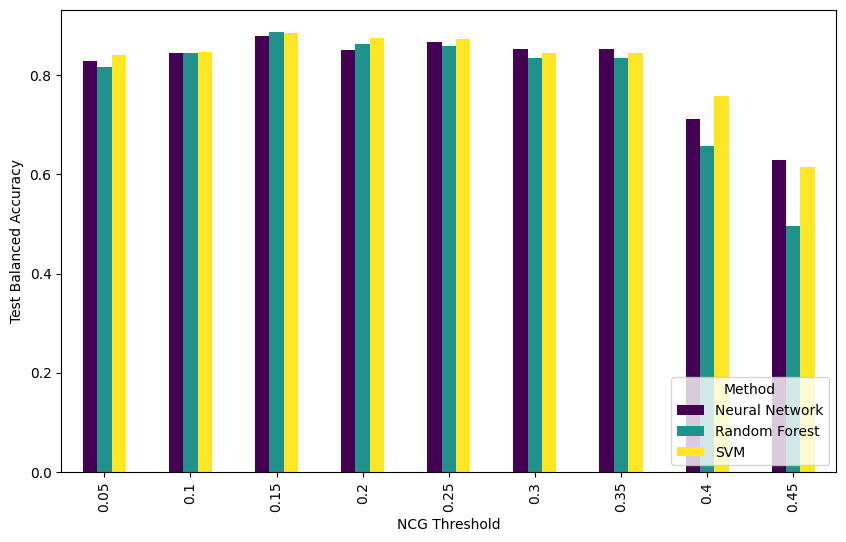

In [ ]:
import matplotlib.pyplot as plt

df = combined_df_total

pivot_df = df.pivot(index='NCG Threshold', columns='Method', values='Test Balanced Accuracy')
# Create a bar plot
pivot_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.xlabel('NCG Threshold')
plt.ylabel('Test Balanced Accuracy')
plt.legend(title='Method', loc='lower right')
# Save the plot as an image file (adjust the filename as needed)
plt.savefig(f'Test_Balanced_Accuracy_dataframe_plot.png')

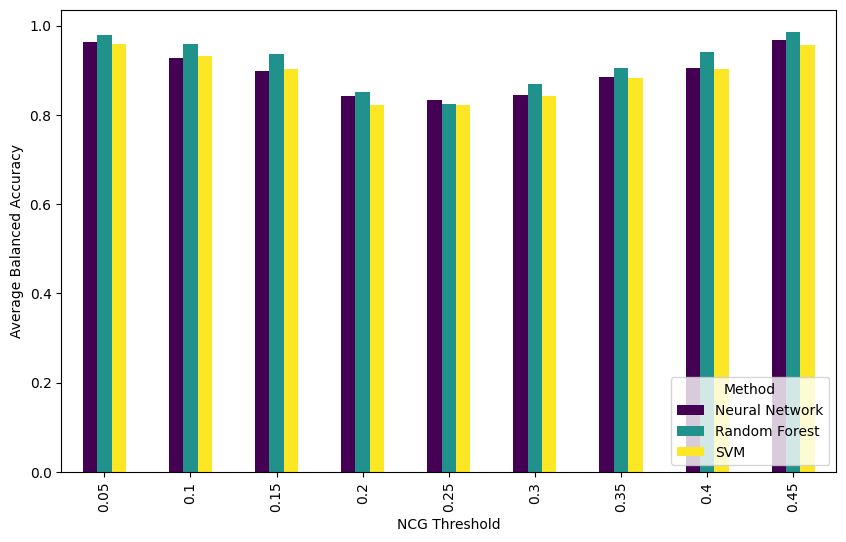

In [ ]:
# Pivot the DataFrame for plotting
pivot_df = df.pivot(index='NCG Threshold', columns='Method', values='Average Balanced Accuracy')

# Create a bar plot
pivot_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.xlabel('NCG Threshold')
plt.ylabel('Average Balanced Accuracy')
plt.legend(title='Method', loc='lower right')
# Save the plot as an image file (adjust the filename as needed)
plt.savefig(f'Average_Balanced_Accuracy_dataframe_plot.png')

ANALYSIS FOR CONTROL (CNT) COHORT

In [ ]:

from tabulate import tabulate
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
#We now base binary classification of outputs on different ncg thresholds
# Iterate over thresholds and fit models
#final results are stored in a dataframe combined_df
# Define headers
headers = ["Method","NCG Threshold", "Average Balanced Accuracy", "Std Dev of Balanced Accuracy", "Test Balanced Accuracy"]
combined_df_CNT = pd.DataFrame(columns=headers)

for threshold in thresholds: #looping the evaluate model function over different thresholds

    # defining inputs as X
    X = df_CNT[["AKT_PP","TP53","ERK_PP","E2F1","PTEN","WIP1","CDKN1A","ATM","BAX","CASP9","MDM4","CDK1","CDK2","AR","RB1","ARF","Raf_P","MDM2","CCNG1","BCL2","ERK_PP_CONC","AKT_PP_CONC"]] #,"PTEN", "EGF_nM"]] #[["ERK_PP_CONC", "AKT_PP_CONC"]] #,"PTEN_analog", "EGF"
    # Add an output column to binary based on the ncg threshold
    df_CNT['binary_class'] = (df_CNT['NCG'] > threshold).astype(int)
    y = df_CNT['binary_class']

    # Check if there are at least two unique classes in the binary output
    unique_classes = df_CNT['binary_class'].unique()
    if len(unique_classes) < 2:
        print(f"Skipping threshold {threshold} as it results in only one class in the binary output.")
        continue
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Apply SMOTE to the training set only
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

    # print("Neural Network")
    nn_model = Sequential([
            Dense(10, input_shape=(X_train.shape[1],), activation='tanh'),
            Dense(20, activation='tanh'),
            Dense(40, activation='tanh'),
            Dense(20, activation='tanh'),
            Dense(1)  # No activation function here for logits (raw scores)
        ])
    nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    nn_results = evaluate_model(threshold,nn_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test)

    #print("SVM")

    svm_model = SVC(kernel='rbf', C=10, gamma='scale')
    svm_results = evaluate_model(threshold,svm_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test)

    #print("Random Forest")

    rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_results = evaluate_model(threshold,rf_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test)

    # Display results in a table

    table = tabulate([
    ["Neural Network"] + list(nn_results),
    ["SVM"] + list(svm_results),
    ["Random Forest"] + list(rf_results)
    ], headers, tablefmt='html', floatfmt=".3f")
    print(table)

    # Convert tabulated data to DataFrame
    df_tabulate = pd.read_html(table, flavor='html5lib')[0]

    # Append the DataFrame to the combined DataFrame
    combined_df_CNT = combined_df_CNT.append(df_tabulate, ignore_index=True)



ANALYSIS FOR BR COHORT

In [ ]:

from tabulate import tabulate
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
#We now base binary classification of outputs on different ncg thresholds
# Iterate over thresholds and fit models
#final results are stored in a dataframe combined_df
# Define headers
headers = ["Method","NCG Threshold", "Average Balanced Accuracy", "Std Dev of Balanced Accuracy", "Test Balanced Accuracy"]
combined_df_BR = pd.DataFrame(columns=headers)

for threshold in thresholds: #looping the evaluate model function over different thresholds

    # defining inputs as X
    X = df_BR[["AKT_PP","TP53","ERK_PP","E2F1","PTEN","WIP1","CDKN1A","ATM","BAX","CASP9","MDM4","CDK1","CDK2","AR","RB1","ARF","Raf_P","MDM2","CCNG1","BCL2","ERK_PP_CONC","AKT_PP_CONC"]] #,"PTEN", "EGF_nM"]] #[["ERK_PP_CONC", "AKT_PP_CONC"]] #,"PTEN_analog", "EGF"
    # Add an output column to binary based on the ncg threshold
    df_BR['binary_class'] = (df_BR['NCG'] > threshold).astype(int)
    y = df_BR['binary_class']

    # Check if there are at least two unique classes in the binary output
    unique_classes = df_BR['binary_class'].unique()
    if len(unique_classes) < 2:
        print(f"Skipping threshold {threshold} as it results in only one class in the binary output.")
        continue
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Apply SMOTE to the training set only
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

    # print("Neural Network")
    nn_model = Sequential([
            Dense(10, input_shape=(X_train.shape[1],), activation='tanh'),
            Dense(20, activation='tanh'),
            Dense(40, activation='tanh'),
            Dense(20, activation='tanh'),
            Dense(1)  # No activation function here for logits (raw scores)
        ])
    nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    nn_results = evaluate_model(threshold,nn_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test)

    #print("SVM")

    svm_model = SVC(kernel='rbf', C=10, gamma='scale')
    svm_results = evaluate_model(threshold,svm_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test)

    #print("Random Forest")

    rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_results = evaluate_model(threshold,rf_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test)

    # Display results in a table

    table = tabulate([
    ["Neural Network"] + list(nn_results),
    ["SVM"] + list(svm_results),
    ["Random Forest"] + list(rf_results)
    ], headers, tablefmt='html', floatfmt=".3f")
    print(table)

    # Convert tabulated data to DataFrame
    df_tabulate = pd.read_html(table, flavor='html5lib')[0]

    # Append the DataFrame to the combined DataFrame
    combined_df_BR = combined_df_BR.append(df_tabulate, ignore_index=True)



ANALYSIS OF TF COHORT

In [ ]:

from tabulate import tabulate
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
#We now base binary classification of outputs on different ncg thresholds
# Iterate over thresholds and fit models
#final results are stored in a dataframe combined_df
# Define headers
headers = ["Method","NCG Threshold", "Average Balanced Accuracy", "Std Dev of Balanced Accuracy", "Test Balanced Accuracy"]
combined_df_TF = pd.DataFrame(columns=headers)

for threshold in thresholds: #looping the evaluate model function over different thresholds

    # defining inputs as X
    X = df_TF[["AKT_PP","TP53","ERK_PP","E2F1","PTEN","WIP1","CDKN1A","ATM","BAX","CASP9","MDM4","CDK1","CDK2","AR","RB1","ARF","Raf_P","MDM2","CCNG1","BCL2","ERK_PP_CONC","AKT_PP_CONC"]] #,"PTEN", "EGF_nM"]] #[["ERK_PP_CONC", "AKT_PP_CONC"]] #,"PTEN_analog", "EGF"
    # Add an output column to binary based on the ncg threshold
    df_TF['binary_class'] = (df_TF['NCG'] > threshold).astype(int)
    y = df_TF['binary_class']

    # Check if there are at least two unique classes in the binary output
    unique_classes = df_TF['binary_class'].unique()
    if len(unique_classes) < 2:
        print(f"Skipping threshold {threshold} as it results in only one class in the binary output.")
        continue
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Feature scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Apply SMOTE to the training set only
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

    # print("Neural Network")
    nn_model = Sequential([
            Dense(10, input_shape=(X_train.shape[1],), activation='tanh'),
            Dense(20, activation='tanh'),
            Dense(40, activation='tanh'),
            Dense(20, activation='tanh'),
            Dense(1)  # No activation function here for logits (raw scores)
        ])
    nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    nn_results = evaluate_model(threshold,nn_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test)

    #print("SVM")

    svm_model = SVC(kernel='rbf', C=10, gamma='scale')
    svm_results = evaluate_model(threshold,svm_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test)

    #print("Random Forest")

    rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_results = evaluate_model(threshold,rf_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test)

    # Display results in a table

    table = tabulate([
    ["Neural Network"] + list(nn_results),
    ["SVM"] + list(svm_results),
    ["Random Forest"] + list(rf_results)
    ], headers, tablefmt='html', floatfmt=".3f")
    print(table)

    # Convert tabulated data to DataFrame
    df_tabulate = pd.read_html(table, flavor='html5lib')[0]

    # Append the DataFrame to the combined DataFrame
    combined_df_TF = combined_df_TF.append(df_tabulate, ignore_index=True)



In [ ]:
# Create an ExcelWriter object to save multiple sheets in excel file
with pd.ExcelWriter('output_combined.xlsx') as writer:
    # Format numerical entries to three decimal places for each dataset
    for i, df in enumerate([combined_df_CNT, combined_df_BR, combined_df_TF]):
        # Save each DataFrame to a separate sheet
        df.to_excel(writer, sheet_name=f'Sheet_{i + 1}', index=False)

        # Display the DataFrame
        print(f"\nDataFrame {i + 1}:\n{df}")


PLOTS FOR AVG BALANCED ACCURACY ACROSS METHODS IN ALL COHORTS

In [ ]:
import matplotlib.pyplot as plt

dataframes = [combined_df_CNT, combined_df_BR, combined_df_TF]

for i, df in enumerate(dataframes):
    # Pivot the DataFrame for plotting
    pivot_df = df.pivot(index='NCG Threshold', columns='Method', values='Average Balanced Accuracy')

    # Create a bar plot
    pivot_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
    plt.title(f'Methods for {i+1}')
    plt.xlabel('NCG Threshold')
    plt.ylabel('Average Balanced Accuracy')
    plt.legend(title='Method', loc='lower right')
    # Save the plot as an image file (adjust the filename as needed)
    plt.savefig(f'Average_Balanced_Accuracy_dataframe_{i+1}_plot.png')
plt.tight_layout()
plt.show()




PLOTS FOR TEST BALANCED ACCURACY ACROSS METHODS IN ALL COHORTS

In [ ]:
dataframes = [combined_df_CNT, combined_df_BR, combined_df_TF]
#CNT-1, BR-2,TF-3
for i, df in enumerate(dataframes):
    # Pivot the DataFrame for plotting
    pivot_df = df.pivot(index='NCG Threshold', columns='Method', values='Test Balanced Accuracy')

    # Create a bar plot
    pivot_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
    plt.title(f'Methods for {i+1}')
    plt.xlabel('NCG Threshold')
    plt.ylabel('Test Balanced Accuracy')
    plt.legend(title='Method', loc='lower right')
    # Save the plot as an image file (adjust the filename as needed)
    plt.savefig(f'Test_Balanced_Accuracy_dataframe_{i+1}_plot.png')

plt.tight_layout()
plt.show()


Hyperparameter tuning for NN, RF and SVM

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# defining inputs as X
X = df_total[["AKT_PP","TP53","ERK_PP","E2F1","PTEN","WIP1","CDKN1A","ATM","BAX","CASP9","MDM4","CDK1","CDK2","AR","RB1","ARF","Raf_P","MDM2","CCNG1","BCL2","ERK_PP_CONC","AKT_PP_CONC","PTEN", "EGF_nM"]] #[["ERK_PP_CONC", "AKT_PP_CONC"]] #,"PTEN_analog", "EGF"
    # Add an output column to binary based on the ncg threshold
df_total['binary_class'] = (df_total['NCG'] > 0.15).astype(int)
y=df_total['binary_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE to the training set only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)


X_train = X_train_resampled
y_train = y_train_resampled
# Hyperparameter tuning for Neural Network
nn_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
}

nn_clf = MLPClassifier(max_iter=1000, random_state=42)
nn_grid_search = GridSearchCV(nn_clf, nn_param_grid, cv=3, n_jobs=-1)
nn_grid_search.fit(X_train, y_train)
print("Best parameters for Neural Network:", nn_grid_search.best_params_)

# Hyperparameter tuning for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

rf_clf = RandomForestClassifier(random_state=42)
rf_grid_search = GridSearchCV(rf_clf, rf_param_grid, cv=3, n_jobs=-1)
rf_grid_search.fit(X_train, y_train)
print("Best parameters for Random Forest:", rf_grid_search.best_params_)

# Hyperparameter tuning for Support Vector Machine
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
}

svm_clf = SVC(random_state=42)
svm_grid_search = GridSearchCV(svm_clf, svm_param_grid, cv=3, n_jobs=-1)
svm_grid_search.fit(X_train, y_train)
print("Best parameters for Support Vector Machine:", svm_grid_search.best_params_)


Best parameters for Neural Network: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50, 50), 'learning_rate': 'constant', 'solver': 'adam'}


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


Best parameters for Random Forest: {'max_depth': None, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best parameters for Support Vector Machine: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


Looking at the distribution of NCG for all three cohorts

In [ ]:
import seaborn as sns

for i, df in enumerate([df_CNT, df_BR, df_TF]):
     sns.histplot(data=df, x='NCG', kde=True)  # Use kde=False if you don't want the kernel density estimate
     plt.title(f'Distribution of NCG for {i+1}')
     plt.xlabel('Values')
     plt.ylabel('Frequency')
     plt.show()

Feature Ranking

In [ ]:
!pip install shap
import shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 535.7/535.7 kB 6.5 MB/s eta 0:00:00


In [ ]:
# Define your neural network architecture
# def create_model(input_shape):
#     inputs = Input(shape=input_shape)
#     x = Dense(64, activation='relu')(inputs)
#     x = Dense(32, activation='relu')(x)
#     outputs = Dense(1, activation='sigmoid')(x)  # Binary classifier with sigmoid activation
#     model = Model(inputs=inputs, outputs=outputs)
#     return model

# # Generate synthetic data (replace with your own dataset)
# num_samples = 1000
# num_features = 10
# X_train = np.random.randn(num_samples, num_features)
# y_train = np.random.randint(0, 2, size=num_samples)

# # Create and compile your neural network model
# input_shape = (num_features,)
# model = create_model(input_shape)
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # Train the model (replace with your own training procedure)
# model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)
shap.initjs()
# defining inputs as X
threshold=0.15
X = df_total[["AKT_PP","TP53","ERK_PP","E2F1","PTEN","WIP1","CDKN1A","ATM","BAX","CASP9","MDM4","CDK1","CDK2","AR","RB1","ARF","Raf_P","MDM2","CCNG1","BCL2","ERK_PP_CONC","AKT_PP_CONC"]] #,"PTEN", "EGF_nM"]] #[["ERK_PP_CONC", "AKT_PP_CONC"]] #,"PTEN_analog", "EGF"
# Add an output column to binary based on the ncg threshold
df_total['binary_class'] = (df_total['NCG'] > threshold).astype(int)
y = df_total['binary_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE to the training set only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# print("Neural Network")
nn_model = Sequential([
            Dense(10, input_shape=(X_train.shape[1],), activation='relu'),
            Dense(20, activation='relu'),
            Dense(40, activation='relu'),
            Dense(20, activation='relu'),
            Dense(1, activation='sigmoid')  # No activation function here for logits (raw scores)
   ])
nn_model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
#nn_results = evaluate_model(threshold,nn_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test)
nn_model.fit(X_train_resampled, y_train_resampled, epochs=10)


Epoch 1/10
78/78 [==============================] - 3s 10ms/step - loss: 0.5777 - accuracy: 0.7044
Epoch 2/10
78/78 [==============================] - 1s 9ms/step - loss: 0.3514 - accuracy: 0.8502
Epoch 3/10
78/78 [==============================] - 1s 7ms/step - loss: 0.2876 - accuracy: 0.8803
Epoch 4/10
78/78 [==============================] - 1s 7ms/step - loss: 0.2680 - accuracy: 0.8871
Epoch 5/10
78/78 [==============================] - 1s 7ms/step - loss: 0.2604 - accuracy: 0.8956
Epoch 6/10
78/78 [==============================] - 0s 6ms/step - loss: 0.2557 - accuracy: 0.8916
Epoch 7/10
78/78 [==============================] - 1s 9ms/step - loss: 0.2528 - accuracy: 0.8948
Epoch 8/10
78/78 [==============================] - 1s 7ms/step - loss: 0.2460 - accuracy: 0.8948
Epoch 9/10
78/78 [==============================] - 0s 5ms/step - loss: 0.2436 - accuracy: 0.8960
Epoch 10/10
78/78 [==============================] - 0s 4ms/step - loss: 0.2406 - accuracy: 0.8992


In [ ]:

# Initialize the SHAP explainer with your trained model
X_train=X_train_resampled
K=1
background_summary = shap.sample(X_train, K)
explainer = shap.KernelExplainer(nn_model.predict,background_summary)
shap_values = explainer.shap_values(X_train,nsamples=500)



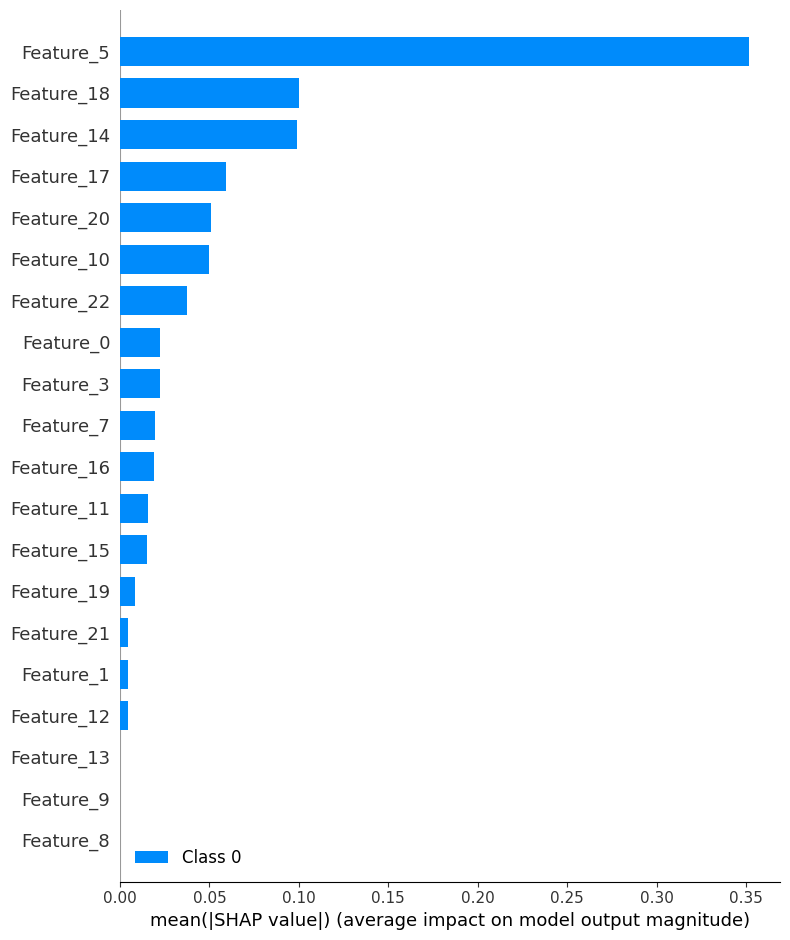

Shapley values for the first sample:
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  3.96677395e-02
  -7.99755255e-05 -7.92887866e-02]
 [-2.15901001e-02  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
  -3.62703577e-06 -2.40313580e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -3.34951371e-02
   3.31302484e-07  4.18474376e-03]
 ...
 [-1.43611315e-02  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
  -1.10258892e-03 -2.30578815e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ... -9.50700295e-02
  -2.72621090e-05 -8.31306657e-03]
 [-3.30145980e-02  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
  -3.46141309e-03 -9.90394826e-02]]


In [ ]:
num_features = X_train.shape[0]
# Plot summary plot (optional)
shap.summary_plot(shap_values, X_train, feature_names=[f"Feature_{i}" for i in range(num_features)])

# Access individual Shapley values for each sample and feature
print("Shapley values for the first sample:")
print(shap_values[0])

# # Access global feature importance ranking
# global_importance_ranking = np.abs(np.mean(shap_values, axis=0))
# sorted_indices = np.argsort(global_importance_ranking)[::-1]
# print("Global feature importance ranking:")
# for i, idx in enumerate(sorted_indices):
#     print(f"{i+1}. Feature_{idx}: {global_importance_ranking[idx]}")

In [ ]:
#   X = df_total[["AKT_PP","TP53","ERK_PP","E2F1","PTEN","WIP1","CDKN1A","ATM","BAX","CASP9","MDM4","CDK1","CDK2","AR","RB1","ARF","Raf_P","MDM2","CCNG1","BCL2","ERK_PP_CONC","AKT_PP_CONC"]] #,"PTEN", "EGF_nM"]] #[["ERK_PP_CONC", "AKT_PP_CONC"]] #,"PTEN_analog", "EGF"
      #               1       2       3       4      5      6       7       8   9      10      11     12     13     14   15     16   17     18      19      20       21           22

array([[-0.80064077, -0.29242498,  0.        , ...,  0.75216304,
        -0.17218032,  0.20039054],
       [ 1.2489996 , -0.29242498,  0.        , ..., -1.32949899,
        -0.17264388, -0.31829078],
       [-0.80064077, -0.29242498,  0.        , ...,  0.75216304,
        -0.17268923, -0.63494071],
       ...,
       [ 1.2489996 , -0.29242498,  0.        , ..., -1.32949899,
        -0.15580501,  1.28387962],
       [-0.80064077, -0.29242498,  0.        , ...,  0.75216304,
        -0.17248318, -0.41528829],
       [ 1.2489996 , -0.29242498,  0.        , ..., -1.32949899,
        -0.15271947, -0.07748992]])